In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install wfdb seaborn

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 123.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you 

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
DATASET_PATH = '/content/drive/MyDrive/mitbih_dataset/'

In [18]:
records = [
'100','101','102','103','104','105','106','107','108','109',
'111','112','113','114','115','116','117','118','119','121',
'122','123','124','200','201','202','203','205','207','208',
'209','210','212','213','214','215','217','219','220','221',
'222','223','228','230','231','232','233','234'
]

In [19]:
import wfdb

for rec in records:
    record = wfdb.rdrecord(DATASET_PATH + rec)
    ann = wfdb.rdann(DATASET_PATH + rec, 'atr')

    print(f"Loaded {rec}")

Loaded 100
Loaded 101
Loaded 102
Loaded 103
Loaded 104
Loaded 105
Loaded 106
Loaded 107
Loaded 108
Loaded 109
Loaded 111
Loaded 112
Loaded 113
Loaded 114
Loaded 115
Loaded 116
Loaded 117
Loaded 118
Loaded 119
Loaded 121
Loaded 122
Loaded 123
Loaded 124
Loaded 200
Loaded 201
Loaded 202
Loaded 203
Loaded 205
Loaded 207
Loaded 208
Loaded 209
Loaded 210
Loaded 212
Loaded 213
Loaded 214
Loaded 215
Loaded 217
Loaded 219
Loaded 220
Loaded 221
Loaded 222
Loaded 223
Loaded 228
Loaded 230
Loaded 231
Loaded 232
Loaded 233
Loaded 234


In [20]:
import os

print(os.listdir('/content/drive/MyDrive/mitbih_dataset')[:10])

['100.hea', '106.hea', '100.dat', '100.atr', '101.hea', '106.dat', '101.dat', '106.atr', '107.hea', '101.atr']


In [22]:

label_map = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    'Q': 4, '/': 4, 'f': 4
}

In [23]:

def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360):
    b, a = butter(3, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

In [24]:

def normalize(signal):
    return (signal - np.mean(signal)) / np.std(signal)


In [ ]:
all_beats = []
all_labels = []

for rec in records:
    try:
        path = os.path.join(DATASET_PATH, rec)

        record = wfdb.rdrecord(path)
        ann = wfdb.rdann(path, 'atr')

        signal = record.p_signal[:, 0]

        signal = bandpass_filter(signal)
        signal = normalize(signal)

        r_peaks = ann.sample
        symbols = ann.symbol
        for r, sym in zip(r_peaks, symbols):

            if sym not in label_map:
                continue

            start = r - 90
            end = r + 90   

            if start >= 0 and end < len(signal):
                beat = signal[start:end]

                all_beats.append(beat)
                all_labels.append(label_map[sym])

        print(f"{rec} processed | Beats: {len(all_beats)}")

    except Exception as e:
        print(f"Error in {rec}: {e}")

 100 processed | Beats: 2271
 101 processed | Beats: 4135
 102 processed | Beats: 6322
 103 processed | Beats: 8406
 104 processed | Beats: 10634
 105 processed | Beats: 13206
 106 processed | Beats: 15233
 107 processed | Beats: 17370
 108 processed | Beats: 19132
 109 processed | Beats: 21663
 111 processed | Beats: 23787
 112 processed | Beats: 26326
 113 processed | Beats: 28120
 114 processed | Beats: 29999
 115 processed | Beats: 31951
 116 processed | Beats: 34362
 117 processed | Beats: 35896
 118 processed | Beats: 38173
 119 processed | Beats: 40160
 121 processed | Beats: 42023
 122 processed | Beats: 44498
 123 processed | Beats: 46015
 124 processed | Beats: 47634
 200 processed | Beats: 50234
 201 processed | Beats: 52197
 202 processed | Beats: 54333
 203 processed | Beats: 57313
 205 processed | Beats: 59969
 207 processed | Beats: 61828
 208 processed | Beats: 64781
 209 processed | Beats: 67786
 210 processed | Beats: 70434
 212 processed | Beats: 73181
 213 processed

In [40]:
X = np.array(all_beats)
y = np.array(all_labels)

print("Shape:", X.shape)
print("Labels:", np.bincount(y))

Shape: (109466, 187)
Labels: [90606  2781  7235   802  8042]


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [42]:
from torch.utils.data import WeightedRandomSampler

class_counts = np.bincount(y_train)
weights = 1. / class_counts

sample_weights = [weights[label] for label in y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [43]:
import torch

def to_tensor(x, y):
    return torch.tensor(x).float().unsqueeze(1), torch.tensor(y).long()

X_train, y_train = to_tensor(X_train, y_train)
X_val, y_val = to_tensor(X_val, y_val)
X_test, y_test = to_tensor(X_test, y_test)

In [44]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=64, sampler=sampler)

val_loader = DataLoader(TensorDataset(X_val, y_val),
                        batch_size=64)

test_loader = DataLoader(TensorDataset(X_test, y_test),
                         batch_size=64)

In [45]:
import torch.nn as nn

class ECG_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 16, 5)
        self.conv2 = nn.Conv1d(16, 32, 5)
        self.pool = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(32*43, 64)
        self.fc2 = nn.Linear(64, 5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [46]:
import torch.optim as optim

model = ECG_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [47]:
epochs = 20

train_losses, val_losses, test_losses = [], [], []
train_acc, val_acc, test_acc = [], [], []

for epoch in range(epochs):

    model.train()
    total, correct, loss_sum = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        pred = output.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = loss_sum / len(train_loader)
    train_accuracy = correct / total

    model.eval()
    total, correct, loss_sum = 0, 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            output = model(x)
            loss = criterion(output, y)

            loss_sum += loss.item()
            pred = output.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    val_loss = loss_sum / len(val_loader)
    val_accuracy = correct / total

    total, correct, loss_sum = 0, 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            output = model(x)
            loss = criterion(output, y)

            loss_sum += loss.item()
            pred = output.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    test_loss = loss_sum / len(test_loader)
    test_accuracy = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

    train_acc.append(train_accuracy)
    val_acc.append(val_accuracy)
    test_acc.append(test_accuracy)
    print(f"Epoch [{epoch+1:02d}/{epochs}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_accuracy*100:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_accuracy*100:.2f}% | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_accuracy*100:.2f}%")

Epoch [01/20] | Train Loss: 0.3771, Acc: 86.51% | Val Loss: 0.3061, Acc: 89.68% | Test Loss: 0.2951, Acc: 90.00%
Epoch [02/20] | Train Loss: 0.2047, Acc: 92.59% | Val Loss: 0.1980, Acc: 93.21% | Test Loss: 0.1843, Acc: 93.78%
Epoch [03/20] | Train Loss: 0.1647, Acc: 94.00% | Val Loss: 0.1814, Acc: 93.74% | Test Loss: 0.1718, Acc: 94.25%
Epoch [04/20] | Train Loss: 0.1380, Acc: 94.96% | Val Loss: 0.1284, Acc: 95.39% | Test Loss: 0.1194, Acc: 95.76%
Epoch [05/20] | Train Loss: 0.1254, Acc: 95.36% | Val Loss: 0.2058, Acc: 92.55% | Test Loss: 0.1940, Acc: 93.05%
Epoch [06/20] | Train Loss: 0.1144, Acc: 95.75% | Val Loss: 0.1510, Acc: 94.59% | Test Loss: 0.1429, Acc: 94.89%
Epoch [07/20] | Train Loss: 0.1047, Acc: 96.13% | Val Loss: 0.1400, Acc: 94.99% | Test Loss: 0.1347, Acc: 95.29%
Epoch [08/20] | Train Loss: 0.1000, Acc: 96.43% | Val Loss: 0.1291, Acc: 95.26% | Test Loss: 0.1273, Acc: 95.42%
Epoch [09/20] | Train Loss: 0.0942, Acc: 96.54% | Val Loss: 0.0876, Acc: 97.39% | Test Loss: 0.0

In [48]:
import torch

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epochs': epochs
}, '/content/drive/MyDrive/ecg_model.pth')

In [49]:
checkpoint = torch.load('/content/drive/MyDrive/ecg_model.pth', map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [50]:
model.eval()

ECG_CNN(
  (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(1,))
  (conv2): Conv1d(16, 32, kernel_size=(5,), stride=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=1376, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=5, bias=True)
)

In [52]:
def evaluate(loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            pred = output.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

In [53]:
train_final_acc = evaluate(train_loader)
val_final_acc = evaluate(val_loader)
test_final_acc = evaluate(test_loader)

print(f"Final Train Accuracy: {train_final_acc*100:.2f}%")
print(f"Final Val Accuracy: {val_final_acc*100:.2f}%")
print(f"Final Test Accuracy: {test_final_acc*100:.2f}%")

Final Train Accuracy: 99.19%
Final Val Accuracy: 97.67%
Final Test Accuracy: 97.67%


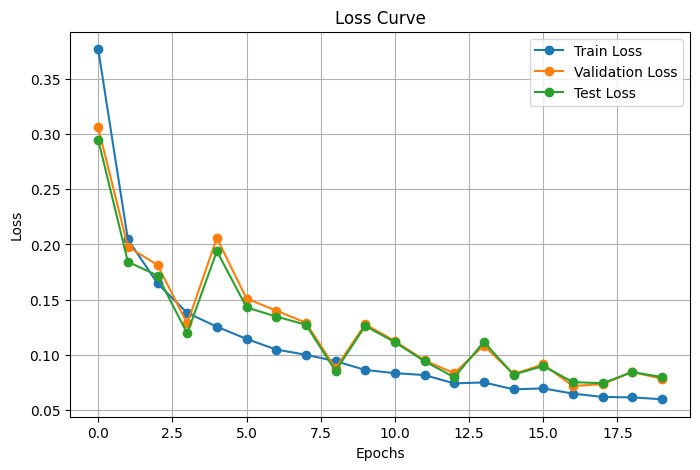

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss", linestyle='-', marker='o')
plt.plot(val_losses, label="Validation Loss", linestyle='-', marker='o')
plt.plot(test_losses, label="Test Loss", linestyle='-', marker='o')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.grid()

plt.show()

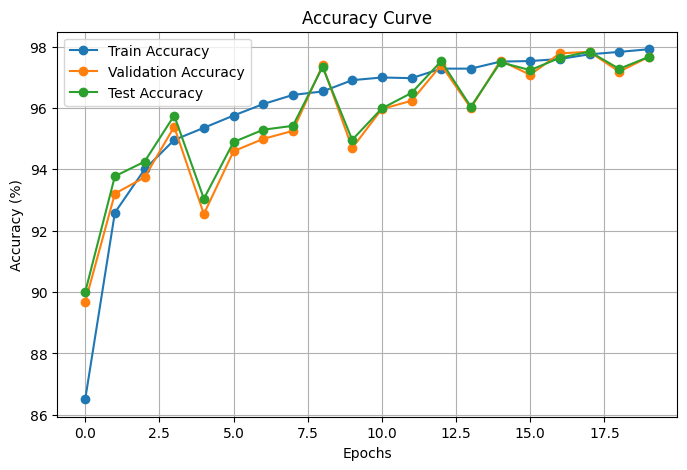

In [55]:
plt.figure(figsize=(8,5))

plt.plot([x*100 for x in train_acc], label="Train Accuracy", linestyle='-', marker='o')
plt.plot([x*100 for x in val_acc], label="Validation Accuracy", linestyle='-', marker='o')
plt.plot([x*100 for x in test_acc], label="Test Accuracy", linestyle='-', marker='o')

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")

plt.legend()
plt.grid()

plt.show()

In [56]:
torch.save(model.state_dict(), '/content/drive/MyDrive/ecg_model.pth')

In [57]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        output = model(x)
        preds = output.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

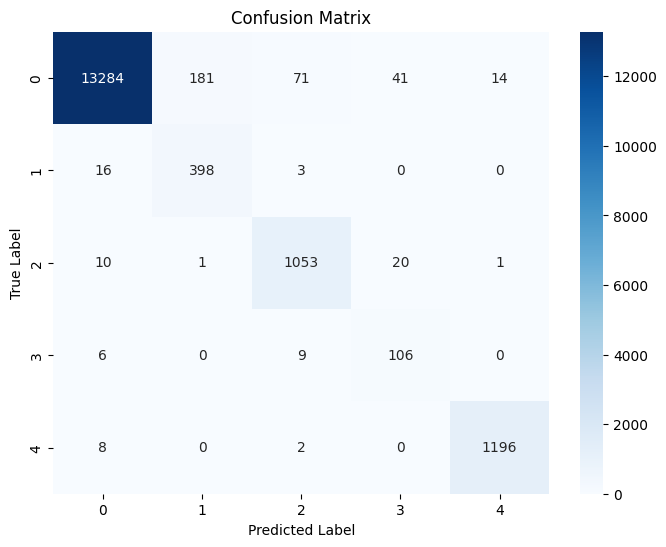

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [59]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9970    0.9774    0.9871     13591
           1     0.6862    0.9544    0.7984       417
           2     0.9253    0.9705    0.9474      1085
           3     0.6347    0.8760    0.7361       121
           4     0.9876    0.9917    0.9897      1206

    accuracy                         0.9767     16420
   macro avg     0.8462    0.9540    0.8917     16420
weighted avg     0.9810    0.9767    0.9780     16420



In [60]:
torch.save(model.state_dict(), '/content/drive/MyDrive/ecg_model.pth')

In [62]:
import numpy as np

np.save('/content/drive/MyDrive/train_losses.npy', train_losses)
np.save('/content/drive/MyDrive/val_losses.npy', val_losses)
np.save('/content/drive/MyDrive/test_losses.npy', test_losses)

np.save('/content/drive/MyDrive/train_acc.npy', train_acc)
np.save('/content/drive/MyDrive/val_acc.npy', val_acc)
np.save('/content/drive/MyDrive/test_acc.npy', test_acc)

In [63]:
np.save('/content/drive/MyDrive/X_test.npy', X_test.cpu().numpy())
np.save('/content/drive/MyDrive/y_test.npy', y_test.cpu().numpy())

In [66]:
import torch
import numpy as np

class_names = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

def predict_ecg(signal):

    model.eval()

    # Convert to tensor
    signal = np.array(signal)
    signal = torch.tensor(signal).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(signal)
        probs = torch.softmax(output, dim=1)

        pred_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_class].item()

    # Multiclass
    multiclass_result = class_names[pred_class]

    # Binary
    binary_result = "Normal" if pred_class == 0 else "Arrhythmia"

    return multiclass_result, binary_result, confidence, probs.cpu().numpy()

In [67]:
print(len(beat))

187


In [114]:
records = ['100', '101', '105', '106', '108', '203', '210']

import wfdb

for rec in records:
    record = wfdb.rdrecord('/content/drive/MyDrive/mitbih_dataset/' + rec)
    ann = wfdb.rdann('/content/drive/MyDrive/mitbih_dataset/' + rec, 'atr')

    print(f"Record {rec} →", set(ann.symbol))

Record 100 → {'V', '+', 'A', 'N'}
Record 101 → {'|', 'Q', 'A', '~', '+', 'N'}
Record 105 → {'|', 'V', 'Q', '~', '+', 'N'}
Record 106 → {'V', '~', '+', 'N'}
Record 108 → {'|', 'x', 'V', 'A', '~', '+', 'N', 'F', 'j'}
Record 203 → {'|', 'a', 'V', 'Q', '~', '+', 'N', 'F'}
Record 210 → {'|', 'a', 'V', 'E', '~', '+', 'N', 'F'}


In [123]:
r_peak = ann.sample[203]   # choose any beat

In [124]:
window_size = 187
half_window = window_size // 2

start = r_peak - half_window
end = r_peak + half_window

beat = signal[start:end]

In [125]:
beat = (beat - np.mean(beat)) / np.std(beat)

In [126]:
print(set(ann.symbol))

{'|', 'a', 'V', 'E', '~', '+', 'N', 'F'}


In [127]:
import matplotlib.pyplot as plt

def plot_ecg(signal, title="ECG Signal"):
    plt.figure(figsize=(10,4))
    plt.plot(signal)
    plt.title(title)
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

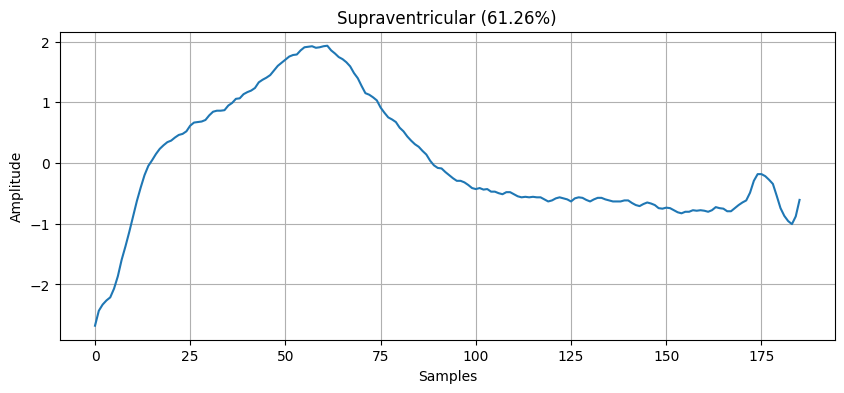

Multiclass: Supraventricular
Binary: Arrhythmia
Confidence: 61.26 %


In [128]:
multi, binary, conf, probs = predict_ecg(beat)

plot_ecg(beat, title=f"{multi} ({conf*100:.2f}%)")

print("Multiclass:", multi)
print("Binary:", binary)
print("Confidence:", round(conf*100, 2), "%")